# Inspect the complete SOLPS-ITER `fort.31` background contract

This notebook decodes and plots the `fort.31` file from one SOLPS-ITER run. It deliberately shows the **complete B2 → EIRENE background file**, not only the four postprocessed source families often used as neural-network targets.

The record order follows `write_f31`/`GFSUB3` in the B2.5 source pinned by `abdoudiaw/SOLPS-ITER` at commit `cb7d15b2878074bb450666bebee4b1df02ef79e6`. Because `fort.31` is headerless, the mesh dimensions are taken from the matching `balance.nc`.

In [1]:
from pathlib import Path
import json
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl-cache")
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

working_directory = Path.cwd()
notebook_directory = (working_directory / "notebooks") if (working_directory / "notebooks").exists() else working_directory
sys.path.insert(0, str(notebook_directory.resolve()))

from fort31_tools import (
    load_balance_geometry, plot_gallery, read_fort31, schema_table,
    summary_table, validate_against_balance,
)

RUN_DIRECTORY = Path(
    "/Users/42d/Library/CloudStorage/Dropbox-ORNL/Abdou Diaw/"
    "SOLPS_DB/ens__DIII-D__APP-FPP__D_C_Ne__ss__lhs__20250124_144649/"
    "run_0a9af338__D"
).expanduser()
FORT31 = RUN_DIRECTORY / "fort.31"
BALANCE = RUN_DIRECTORY / "balance.nc"
assert FORT31.is_file(), FORT31
assert BALANCE.is_file(), BALANCE
RUN_DIRECTORY

PosixPath('/Users/42d/Library/CloudStorage/Dropbox-ORNL/Abdou Diaw/SOLPS_DB/ens__DIII-D__APP-FPP__D_C_Ne__ss__lhs__20250124_144649/run_0a9af338__D')

## Run and file metadata

For the pinned writer, the number of two-dimensional records is `14*NFLAI + 24`, where `NFLAI` is the number of charged fluids handed to EIRENE. Every record includes the guard cells, so its shape is `(ny+2, nx+2)`.

In [2]:
geometry = load_balance_geometry(BALANCE)
fort31 = read_fort31(FORT31, geometry["nx"], geometry["ny"])
params_path = RUN_DIRECTORY / "params.json"
params = json.loads(params_path.read_text()) if params_path.exists() else {}

metadata = pd.Series({
    "run directory": str(RUN_DIRECTORY),
    "fort.31 values": fort31["n_values"],
    "interior nx": fort31["nx"],
    "interior ny": fort31["ny"],
    "charged fluids (NFLAI)": fort31["nflai"],
    "2-D records": fort31["n_records"],
    "expected records (14*NFLAI+24)": 14 * fort31["nflai"] + 24,
    "case identifier": params.get("case_id", params.get("run_id", "not found")),
    "reported converged": params.get("converged", "not found"),
}, name="value")
display(metadata.to_frame())

,value
run directory,/Users/42d/Library/CloudStorage/Dropbox-ORNL/A...
fort.31 values,141512
interior nx,96
interior ny,36
charged fluids (NFLAI),1
2-D records,38
expected records (14*NFLAI+24),38
case identifier,not found
reported converged,not found


## Complete record schema and values

The schema below is the full file contract. A logical field can have one record per charged fluid. The statistics are computed on interior cells only; guard cells remain available in `fort31['fields']`. Temperatures are stored in joules in the file and converted to eV only for plotting.

In [3]:
schema = schema_table(fort31)
stats = summary_table(fort31)
display(schema.style.hide(axis="index"))
display(stats.style.hide(axis="index").format({
    "min": "{:.5e}", "median": "{:.5e}",
    "max": "{:.5e}", "max_abs": "{:.5e}",
}))

field,components,units,description,writer_placeholder
DNIB,1,m^-3,charged-fluid density,False
UUB,1,m s^-1,poloidal velocity,False
VVB,1,m s^-1,radial velocity,False
WWB,1,m s^-1,toroidal velocity,False
TEB,1,J,electron temperature (raw B2/EIRENE unit),False
TIB,1,J,ion temperature (raw B2/EIRENE unit),False
PRB,1,Pa,plasma pressure,False
UPB,1,m s^-1,parallel velocity,False
RRB,1,1,"pitch quantity, documented as Bx/Btot",False
FNIXB,1,s^-1,poloidal ion flow on left face,False


field,component,units,description,writer_placeholder,all_zero,min,median,max,max_abs
DNIB,0,m^-3,charged-fluid density,False,False,6.85162e+16,2.25521e+19,9.27373e+20,9.27373e+20
UUB,0,m s^-1,poloidal velocity,False,False,-2.32601e+03,-1.19978e+01,2.26393e+03,2.32601e+03
VVB,0,m s^-1,radial velocity,False,False,-1.33328e+02,1.27383e+00,1.38693e+01,1.33328e+02
WWB,0,m s^-1,toroidal velocity,False,False,-3.56891e+04,2.00537e+02,2.68729e+04,3.56891e+04
TEB,0,J,electron temperature (raw B2/EIRENE unit),False,False,9.10545e-20,5.16459e-18,1.74631e-16,1.74631e-16
TIB,0,J,ion temperature (raw B2/EIRENE unit),False,False,2.00254e-19,1.33802e-17,1.91643e-16,1.91643e-16
PRB,0,Pa,plasma pressure,False,False,1.24455e-01,6.27624e+02,1.11143e+04,1.11143e+04
UPB,0,m s^-1,parallel velocity,False,False,-2.69734e+04,-2.03636e+02,3.57305e+04,3.57305e+04
RRB,0,1,"pitch quantity, documented as Bx/Btot",False,False,4.38374e-03,6.99251e-02,2.75809e-01,2.75809e-01
FNIXB,0,s^-1,poloidal ion flow on left face,False,False,-2.65404e+22,-6.14711e+18,2.47361e+22,2.65404e+22


## Verify the headerless parser

`DNIB`, `TEB`, and `TIB` also appear in `balance.nc`. Agreement here checks the inferred record count, species ordering, and `(component, y, x)` reshape independently of the plots.

In [4]:
validation = validate_against_balance(fort31, geometry)
display(validation.style.hide(axis="index").format({
    "max_abs_difference": "{:.5e}",
    "max_difference/reference_max": "{:.5e}",
    "correlation": "{:.12f}",
}))

check,max_abs_difference,max_difference/reference_max,correlation
DNIB[0] vs na[1],4.93436e+11,5.32079e-10,1.000000000000
TEB vs te,4.98515e-25,2.85468e-09,1.000000000000
TIB vs ti,4.99991e-25,2.60898e-09,1.000000000000


## Plasma state sent to EIRENE

These are cell-centered plasma/background quantities. Signed fields use a symmetric logarithmic color scale.

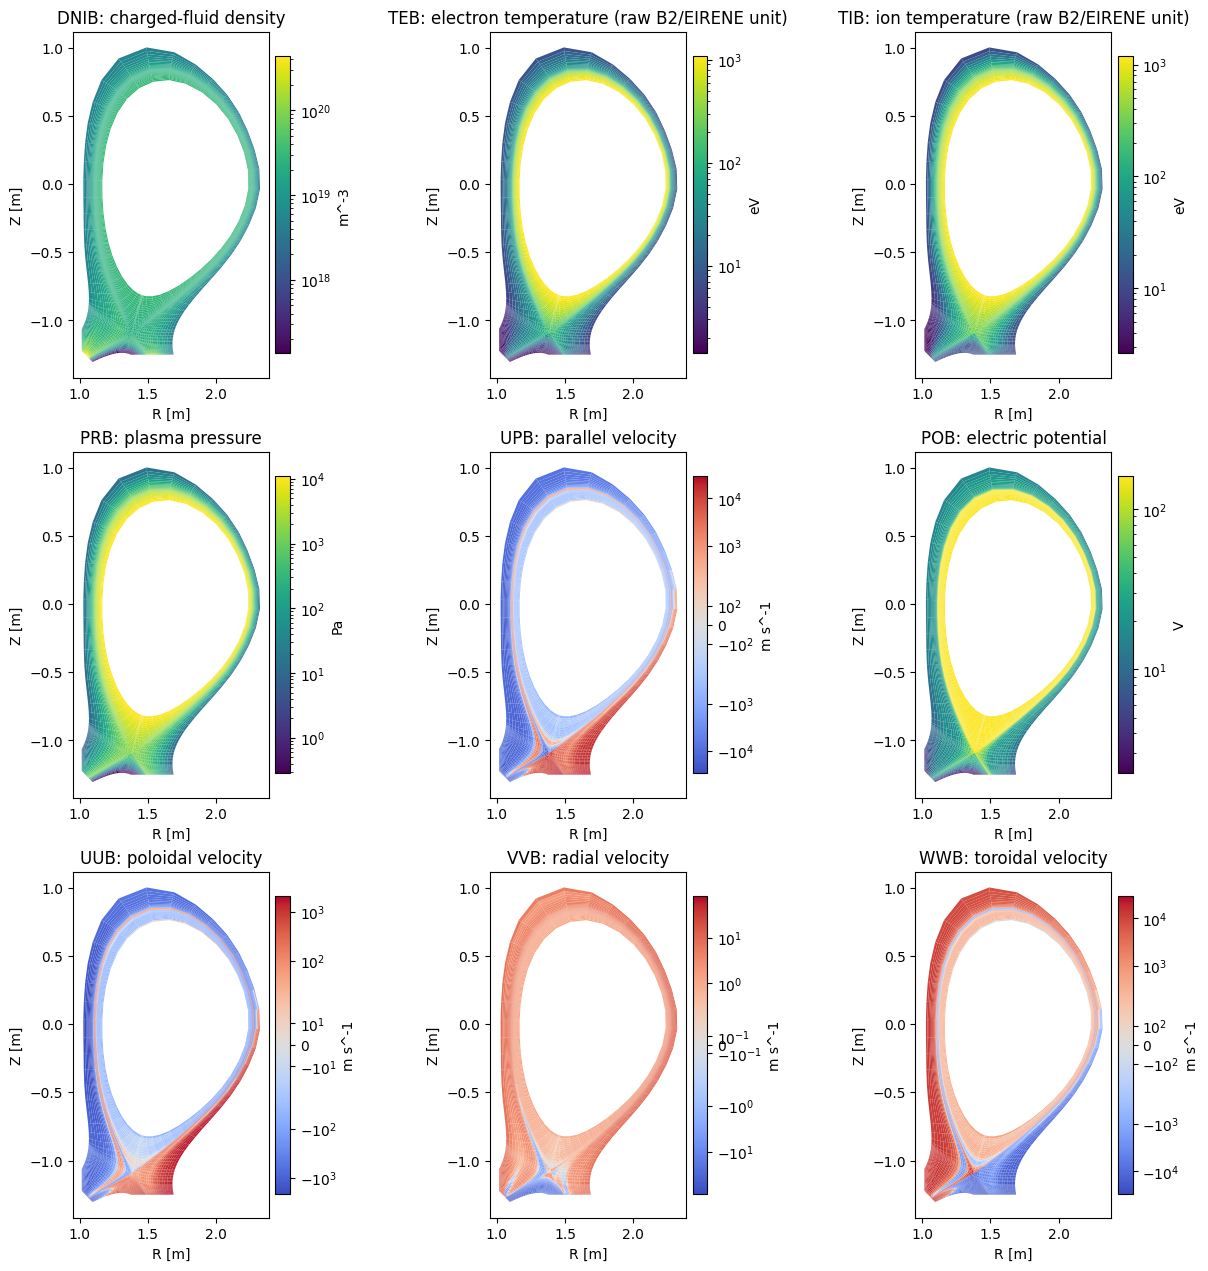

In [5]:
fig, _ = plot_gallery(fort31, geometry, [
    ("DNIB", 0), ("TEB", 0), ("TIB", 0),
    ("PRB", 0), ("UPB", 0), ("POB", 0),
    ("UUB", 0), ("VVB", 0), ("WWB", 0),
], ncols=3)
plt.show()

## Face-integrated particle and energy flows

These six fields are part of the raw background interface too. They should not be silently replaced by only cell-centered density and temperature when choosing an NN input contract.

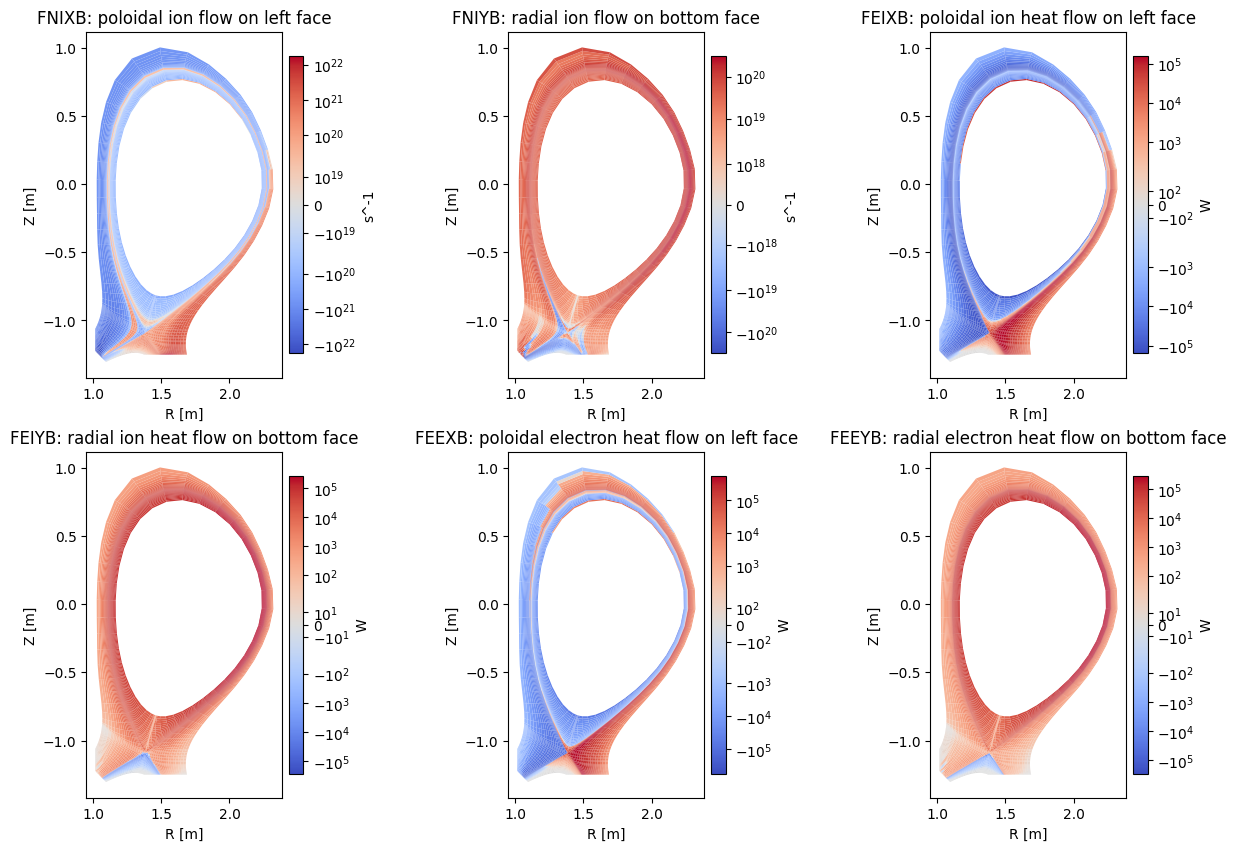

In [6]:
fig, _ = plot_gallery(fort31, geometry, [
    ("FNIXB", 0), ("FNIYB", 0),
    ("FEIXB", 0), ("FEIYB", 0),
    ("FEEXB", 0), ("FEEYB", 0),
], ncols=3)
plt.show()

## Geometry, magnetic field, drifts, and sheath corrections

Some records are zero for this run. They remain part of the writer contract and must be distinguished from fields that are absent.

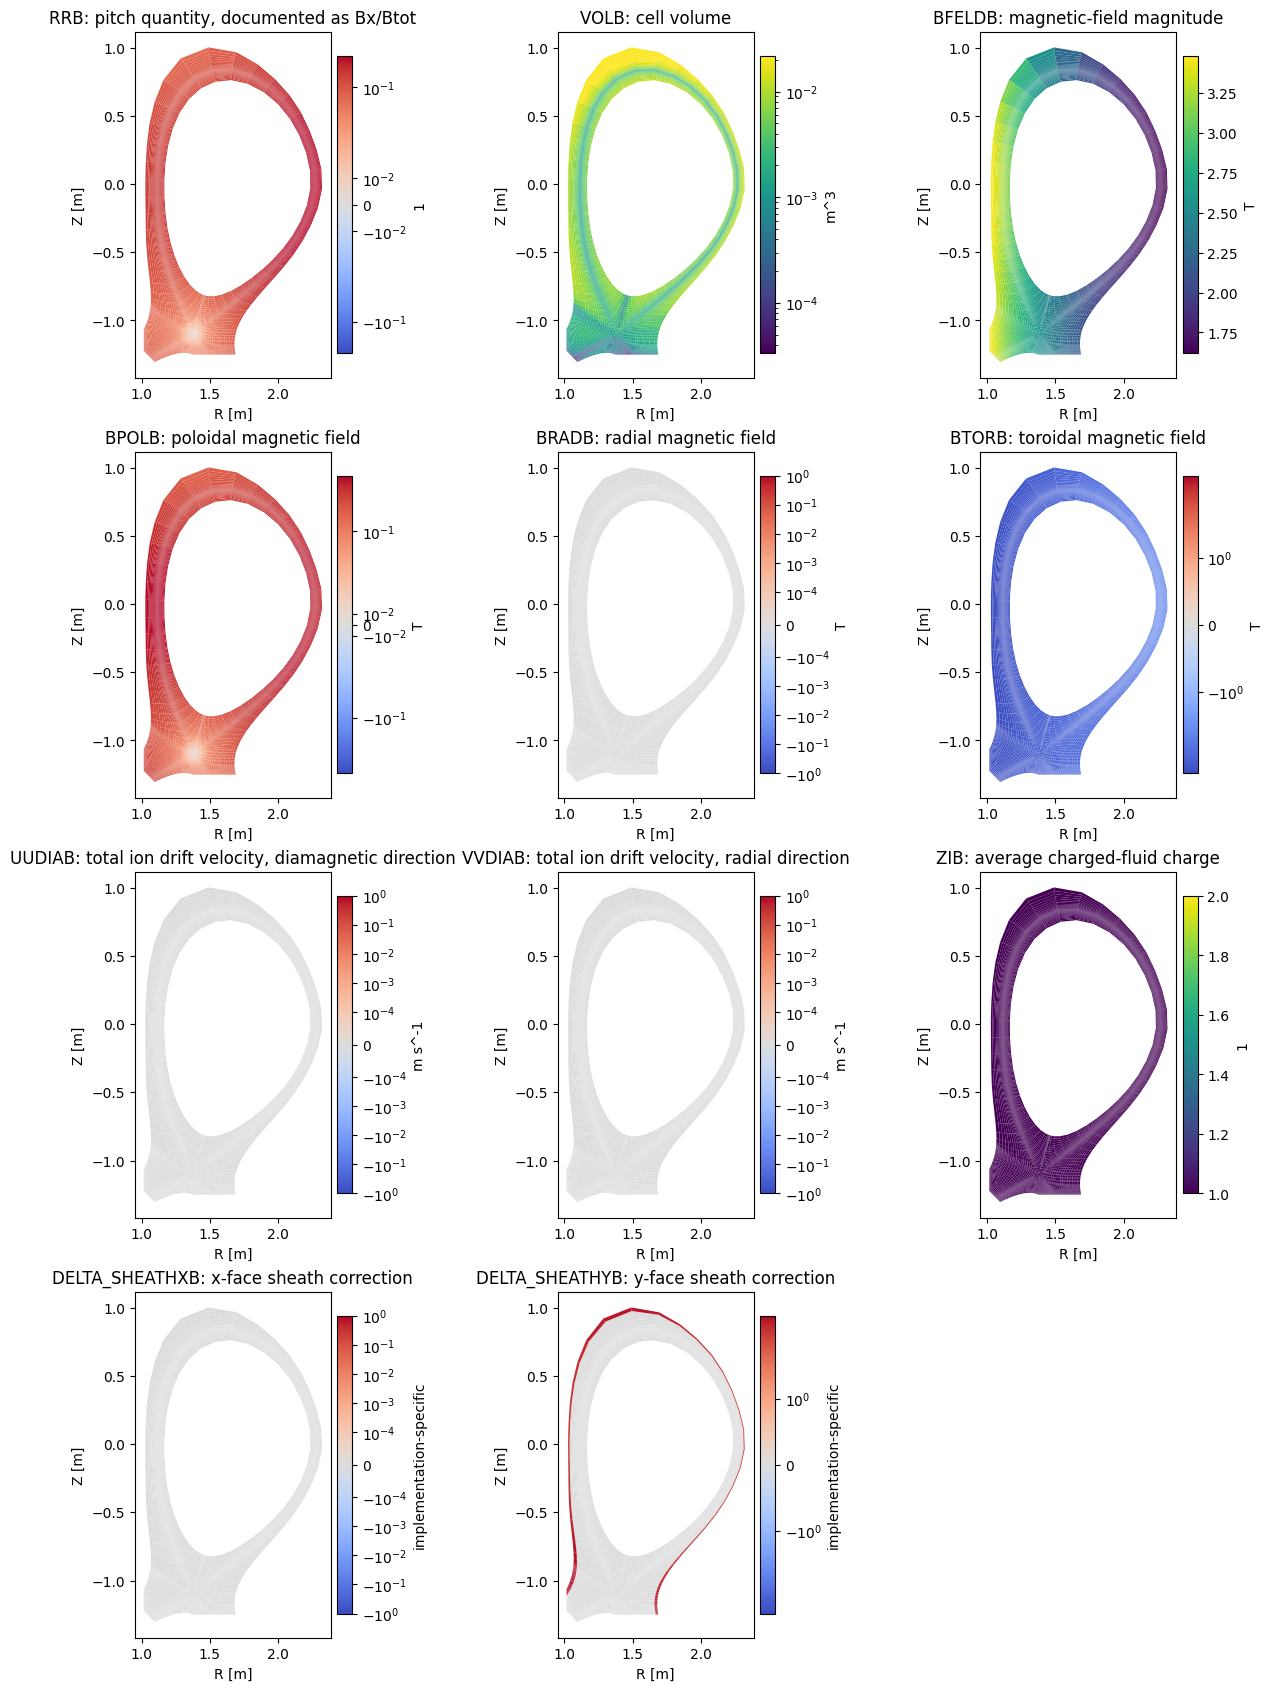

In [7]:
fig, _ = plot_gallery(fort31, geometry, [
    ("RRB", 0), ("VOLB", 0), ("BFELDB", 0),
    ("BPOLB", 0), ("BRADB", 0), ("BTORB", 0),
    ("UUDIAB", 0), ("VVDIAB", 0), ("ZIB", 0),
    ("DELTA_SHEATHXB", 0), ("DELTA_SHEATHYB", 0),
], ncols=3)
plt.show()

## Explicit inventory of zero and placeholder records

A zero array is still an interface record. The `writer_placeholder` flag means the pinned writer deliberately emits a future-use zero block; `all_zero` reports what occurred in this particular run.

In [8]:
zero_or_placeholder = stats.loc[
    stats["all_zero"] | stats["writer_placeholder"],
    ["field", "component", "description", "writer_placeholder", "all_zero", "max_abs"],
]
display(zero_or_placeholder.style.hide(axis="index").format({"max_abs": "{:.5e}"}))
print(f"All-zero record components: {int(stats['all_zero'].sum())} / {len(stats)}")
print(f"Writer-placeholder components: {int(stats['writer_placeholder'].sum())} / {len(stats)}")

field,component,description,writer_placeholder,all_zero,max_abs
UUDIAB,0,"total ion drift velocity, diamagnetic direction",False,True,0.00000e+00
VVDIAB,0,"total ion drift velocity, radial direction",False,True,0.00000e+00
BRADB,0,radial magnetic field,False,True,0.00000e+00
VPARXB,0,future-use parallel x velocity,True,True,0.00000e+00
VPARYB,0,future-use parallel y velocity,True,True,0.00000e+00
VRADXB,0,future-use radial x velocity,True,True,0.00000e+00
VRADYB,0,future-use radial y velocity,True,True,0.00000e+00
DELTAE_PARXB,0,future-use electron parallel x correction,True,True,0.00000e+00
DELTAE_PARYB,0,future-use electron parallel y correction,True,True,0.00000e+00
DELTAE_RADXB,0,future-use electron radial x correction,True,True,0.00000e+00


All-zero record components: 16 / 38
Writer-placeholder components: 12 / 38


## What this means for the surrogate boundary

This file answers only the **B2 → EIRENE** half of the coupling: the two-dimensional plasma state, flows, geometry, magnetic field, and correction records used to initialize an EIRENE call. It is not the set of neutral source terms returned by EIRENE to B2.

Consequently, a model inserted at the raw EIRENE interface cannot be specified as merely four outputs such as particle, momentum, ion-energy, and electron-energy sources. Those are useful reduced targets only at a later, postprocessed B2 seam. At the raw seam the middleware must preserve the full EIRENE → B2 return contract—including species/stratum-resolved channels and statistical information—before B2 performs summation, mapping, clipping, relaxation, or other regularization.

For this run, `fort.31` contains 38 two-dimensional records because `NFLAI=1`. Twelve are explicit future-use placeholders. Other arrays may be zero because the corresponding physics option is inactive here; that does not establish that they can be deleted for a multi-run training corpus.